# Benchmarking models for fugacity coefficients

This notebook benchmarks the models for fugacity coefficients in VolFe where possible.

## Python set-up

In [22]:
import pandas as pd
import VolFe as vf
import math
import matplotlib.pyplot as plt

## Models for fugacity coefficient of H2

options = y_H2, function = y_H2

### 'Shaw64' Eq. (4) from Shaw & Wones (1964)

Note: used a value of -0.011901 instead of -0.11901 as reported for calculation of C3 to match data in Table 2.

Table 3 in Shaw & Wone's contains values for the fugacity coefficient for various P and T.

We spot check ten values here (using values for bars not atmospheres) - they all match to three decimal places.

y = 1.133 (P = 500 bar, T = 500)

y = 1.085 (P = 500 bar, T = 850)

y = 1.073 (P = 500 bar, T = 1000)

y = 1.481 (P = 1600 bar, T = 500)

y = 1.296 (P = 1600 bar, T = 850)

y = 1.252 (P = 1600 bar, T = 1000)

y = 1.749 (P = 2300 bar, T = 500)

y = 1.378 (P = 2300 bar, T = 1000)

y = 1.615 (P = 3000 bar, T = 850)

y = 1.515 (P = 3000 bar, T = 1000)

In [8]:
my_models = [["y_H2", "Shaw64"]]
my_models = vf.make_df_and_add_model_defaults(my_models)

PT = {"P":500.} # bar
PT["T"]=500. # 'C
y = vf.y_H2(PT,models=my_models)
print('y = ', y, '(P =',PT['P'],'bars, T =', PT['T'],')')
PT["T"]=850. # 'C
y = vf.y_H2(PT,models=my_models)
print('y = ', y, '(P =',PT['P'],'bars, T =', PT['T'],')')
PT["T"]=1000. # 'C
y = vf.y_H2(PT,models=my_models)
print('y = ', y, '(P =',PT['P'],'bars, T =', PT['T'],')')
PT = {"P":1600.} # bar
PT["T"]=500. # 'C
y = vf.y_H2(PT,models=my_models)
print('y = ', y, '(P =',PT['P'],'bars, T =', PT['T'],')')
PT["T"]=850. # 'C
y = vf.y_H2(PT,models=my_models)
print('y = ', y, '(P =',PT['P'],'bars, T =', PT['T'],')')
PT["T"]=1000. # 'C
y = vf.y_H2(PT,models=my_models)
print('y = ', y, '(P =',PT['P'],'bars, T =', PT['T'],')')
PT = {"P":2300.} # bar
PT["T"]=500. # 'C
y = vf.y_H2(PT,models=my_models)
print('y = ', y, '(P =',PT['P'],'bars, T =', PT['T'],')')
PT["T"]=1000. # 'C
y = vf.y_H2(PT,models=my_models)
print('y = ', y, '(P =',PT['P'],'bars, T =', PT['T'],')')
PT = {"P":3000.} # bar
PT["T"]=850. # 'C
y = vf.y_H2(PT,models=my_models)
print('y = ', y, '(P =',PT['P'],'bars, T =', PT['T'],')')
PT["T"]=1000. # 'C
y = vf.y_H2(PT,models=my_models)
print('y = ', y, '(P =',PT['P'],'bars, T =', PT['T'],')')


y =  1.1327128811340401 (P = 500.0 bars, T = 500.0 )
y =  1.0853513685035343 (P = 500.0 bars, T = 850.0 )
y =  1.0733936356394882 (P = 500.0 bars, T = 1000.0 )
y =  1.4812384375778227 (P = 1600.0 bars, T = 500.0 )
y =  1.295939045430643 (P = 1600.0 bars, T = 850.0 )
y =  1.2516574282929442 (P = 1600.0 bars, T = 1000.0 )
y =  1.7496048740312717 (P = 2300.0 bars, T = 500.0 )
y =  1.3780736491913488 (P = 2300.0 bars, T = 1000.0 )
y =  1.6148638426007402 (P = 3000.0 bars, T = 850.0 )
y =  1.5154237931859629 (P = 3000.0 bars, T = 1000.0 )


## Models for fugacity coefficient of CO2

options = y_CO2, function = y_CP2

### 'Shi92' Shi & Saxena (1992)

Fig. 6 in Shi & Saxena (1992) shows the volumes of the H2O-CO2 binary mixture for pressures between 1 and 6 kbar and temperature between 400 and 700 'C. The values at pure CO2 (XH2O = 0) can be compared to the calculations in VolFe. The values were extracted from plotdigitizer.com/app

In [27]:
data_yCO2_yH2O_Shi92 = pd.read_csv("materials-from-original-papers/data_y_CO2,y_H2O=Shi92 Fig6_Shi92.csv") 

In [25]:
my_models = [["y_CO2", "Shi92"]]
my_models = vf.make_df_and_add_model_defaults(my_models)

for P in [1000.,2000.,3000.,4000.,5000.,6000.]:
    for T in [400.,500.,600.,700.]:
        PT = {'P':P}
        PT['T'] = T
        vol = 10.*vf.gas_molar_volume('CO2',PT,models=my_models) # in cm3/mol
        results = [[P,T,vol]]
        results = pd.DataFrame(results, columns=['P (bar)', 'T (C)', 'Volume (cm3/mol)'])
        if P == 1000. and T == 400.:
            results_ = results
        else:
            results_ = pd.concat([results_,results], axis=0)
    results_yCO2_Shi92 = results_

(0.0, 7000.0)

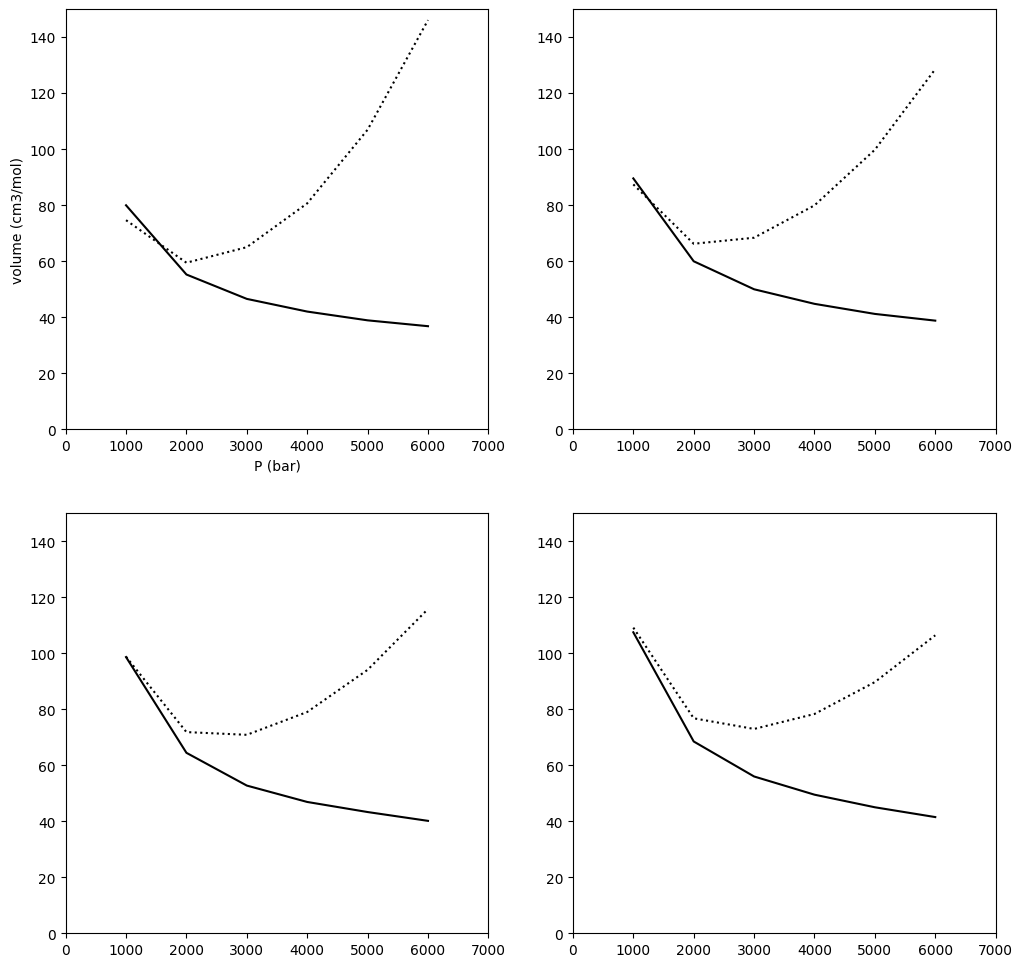

In [40]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(12,12))

data1 = data_yCO2_yH2O_Shi92
data2 = results_yCO2_Shi92 # sulfur can saturate

# Plotting results
T = 400.
ax1.plot(data1[data1['T (C)']==T]['P (bar)'], data1[data1['T (C)']==T]['CO2 V (cm3/mol)'], '-k')
ax1.plot(data2[data2['T (C)']==T]['P (bar)'], data2[data2['T (C)']==T]['Volume (cm3/mol)'], ':k')
T = 500.
ax2.plot(data1[data1['T (C)']==T]['P (bar)'], data1[data1['T (C)']==T]['CO2 V (cm3/mol)'], '-k')
ax2.plot(data2[data2['T (C)']==T]['P (bar)'], data2[data2['T (C)']==T]['Volume (cm3/mol)'], ':k')
T = 600.
ax3.plot(data1[data1['T (C)']==T]['P (bar)'], data1[data1['T (C)']==T]['CO2 V (cm3/mol)'], '-k')
ax3.plot(data2[data2['T (C)']==T]['P (bar)'], data2[data2['T (C)']==T]['Volume (cm3/mol)'], ':k')
T = 700.
ax4.plot(data1[data1['T (C)']==T]['P (bar)'], data1[data1['T (C)']==T]['CO2 V (cm3/mol)'], '-k')
ax4.plot(data2[data2['T (C)']==T]['P (bar)'], data2[data2['T (C)']==T]['Volume (cm3/mol)'], ':k')

ax1.set_xlabel('P (bar)')
ax1.set_ylabel('volume (cm3/mol)')
ax1.set_ylim([0,150])
ax2.set_ylim([0,150])
ax3.set_ylim([0,150])
ax4.set_ylim([0,150])
ax1.set_xlim([0,7000])
ax2.set_xlim([0,7000])
ax3.set_xlim([0,7000])
ax4.set_xlim([0,7000])